Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE" and remove every line containing the expression: "raise ..." (if you leave such a line your code will not run).

Do not remove any cell from the notebook you downloaded. You can add any number of cells (and remove them if not more necessary).

Do not leave any variable initialized to None.

## IMPORTANT: make sure to rerun all the code from the beginning to obtain the results for the final version of your notebook, since this is the way we will do it before evaluating your notebook!!!

## Make sure to name your notebook file (.ipynb) correctly:
### - NL_NAMESURNAME_ID (E.g. : NL_MARIOROSSI_2204567)

## Fill in your name, surname and id number (numero matricola) below:

In [1]:
# Reproducible project seed, not a university registration number.
NAME = "Stelina Mukaj"
ID_number = 42  # Replace with your matricola only if submitting to the course.
import numpy as np
np.random.seed(ID_number)


---

## HOMEWORK #3

### Non linear models for classification 

In this notebook we are going to explore the use of SVM and Neural Networks for image classification. We are going to use the famous MNIST dataset, that is a dataset of handwritten digits. We get the data from mldata.org, that is a public repository for machine learning data.

In [2]:
# Load the required packages
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sn

import sklearn
from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier

np.random.seed(ID_number)


In [3]:
#load the MNIST dataset 
#Load data from https://www.openml.org/d/554
X,Y = fetch_openml('mnist_784', version=1, return_X_y=True,as_frame = False)

print(f'Each image is represented as vector of shape {X[0].shape}')
print(f'The image is represented in gray scale levels {X[0]}')
print(f'Here it is a label: {Y[0]}')


Each image is represented as vector of shape (784,)
The image is represented in gray scale levels [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255
 247 127   0   0   0   0   0   0   0   0   0   0   0   0  30  36  94 154
 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0   0   0
   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82
  82  56  39   0   0   0  

In [4]:
#let's normalize the features so that each value is between [0,1]

# Rescale the data
X = X / 255.


In a classification problem it is desirable to split the dataset into train and test sets in a way that preserves the same proportions of examples in each class as observed in the original dataset.
We can achieve this by setting the “stratify” argument of the function "train_test_split" to the Y component of our dataset.

We are going to use 500 samples in the train dataset, the remaining ones are used for testing.

In [5]:
from sklearn.model_selection import train_test_split

m_t = 500
x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size=m_t, random_state=ID_number, stratify=Y)

print(f'Lenght train dataset: {len(y_train)}, Labels and frequencies: \n {list(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Lenght test dataset: {len(y_test)}, Labels and frequencies: \n {list(zip(*np.unique(y_test, return_counts=True)))}')


Lenght train dataset: 500, Labels and frequencies: 
 [('0', np.int64(49)), ('1', np.int64(56)), ('2', np.int64(50)), ('3', np.int64(51)), ('4', np.int64(49)), ('5', np.int64(45)), ('6', np.int64(49)), ('7', np.int64(52)), ('8', np.int64(49)), ('9', np.int64(50))]
Lenght test dataset: 69500, Labels and frequencies: 
 [('0', np.int64(6854)), ('1', np.int64(7821)), ('2', np.int64(6940)), ('3', np.int64(7090)), ('4', np.int64(6775)), ('5', np.int64(6268)), ('6', np.int64(6827)), ('7', np.int64(7241)), ('8', np.int64(6776)), ('9', np.int64(6908))]


In [6]:
# Function to plot a digit and print the corresponding label
def plot_digit(X_matrix, labels, index):
    print("INPUT:")
    plt.imshow(
        X_matrix[index].reshape(28,28),
        cmap          = plt.cm.gray_r,
        interpolation = "nearest"
    )
    plt.show()
    print(f"LABEL: {labels[index]}")
    return


INPUT:
LABEL: 1
INPUT:
LABEL: 1


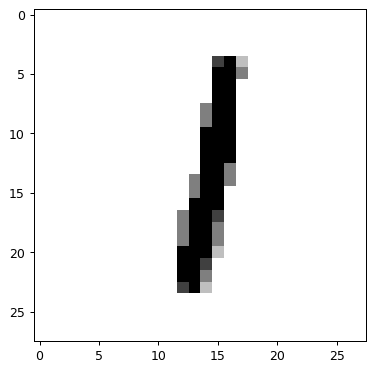

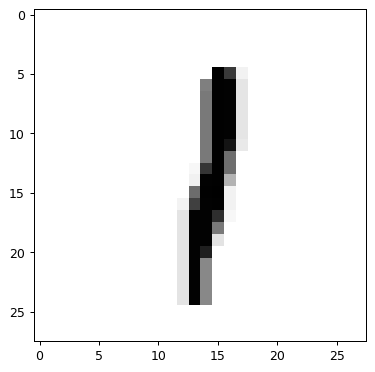

In [7]:
#let's try the plotting function
plot_digit(x_train, y_train, 100)
plot_digit(x_test, y_test, 40000)


## TO DO 1
SVM with cross validation to pick the best model. Use SVC from sklearn.svm and GridSearchCV from sklearn.model_selection (5-fold cross-validation).

Print the best parameters found as well as the best score obtained by the 'optimal' model.
Choose the grid, depending on the kernel you are using different hyper-parameters are needed (C, gamma, ...). 
You do not need to use more than 5 values for each hyper-parameter (otherwise the cell could be very slow). 

In [8]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

def compute_best_SVM_with_CV(kernel_type,parameters,x_train,y_train):
    cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=ID_number)
    search = GridSearchCV(SVC(kernel=kernel_type),parameters,cv=cv,scoring='accuracy',n_jobs=1)
    search.fit(x_train,y_train)
    print(kernel_type,search.best_params_,"CV accuracy:",search.best_score_)
    return search.best_params_,np.float64(search.best_score_),search.cv_results_['mean_test_score']

linear_parameters = {'C':[0.1,1,10]}
rbf_parameters = {'C':[1,10,100],'gamma':['scale',0.01,0.1]}
poly_parameters = {'C':[0.1,1,10],'degree':[2,3],'gamma':['scale'],'coef0':[0,1]}
best_param_lin,best_score_lin,all_scores_lin = compute_best_SVM_with_CV('linear',linear_parameters,x_train,y_train)
best_param_rbf,best_score_rbf,all_scores_rbf = compute_best_SVM_with_CV('rbf',rbf_parameters,x_train,y_train)
best_param_poly,best_score_poly,all_scores_poly = compute_best_SVM_with_CV('poly',poly_parameters,x_train,y_train)


linear {'C': 0.1} CV accuracy: 0.8539999999999999
rbf {'C': 10, 'gamma': 0.01} CV accuracy: 0.892
poly {'C': 1, 'coef0': 0, 'degree': 2, 'gamma': 'scale'} CV accuracy: 0.8720000000000001


In [9]:
assert type(best_param_rbf) == dict
assert type(best_score_rbf) == np.float64
assert np.prod(np.array([len(params) for params in rbf_parameters.values()])) == len(all_scores_rbf)


In [10]:
svm_candidates = [('linear',best_param_lin,best_score_lin),('rbf',best_param_rbf,best_score_rbf),('poly',best_param_poly,best_score_poly)]
best_kernel_type,best_parameters,best_svm_cv_score = max(svm_candidates,key=lambda r:r[2])
best_SVM = SVC(kernel=best_kernel_type,**best_parameters).fit(x_train,y_train)
training_error = np.float64(1-best_SVM.score(x_train,y_train))
test_error = np.float64(1-best_SVM.score(x_test,y_test))
svm_small_errors = (training_error,test_error)
print("Best kernel:",best_kernel_type,"Training error:",training_error,"Test error:",test_error)


Best kernel: rbf Training error: 0.0 Test error: 0.10601438848920863


In [11]:
assert type(training_error) == np.float64
assert type(test_error) == np.float64


### TO DO 3
Now we use feed-forward neural networks for classification. 
In particular, we use the Multi-Layer-Perceptron (the multi-layer structure we have seen in class, see http://scikit-learn.org/stable/modules/neural_networks_supervised.html).

Similarly as before, we use cross validation to pick the best model, you need to complete the function 'compute_best_MLP_with_CV()' that finds the best MLP architecture given a specific activation function.

Note that the starting random state is fixed to make the runs reproducible (random_state=ID_number).
The following options for the MLP are used: max_iter=1000, alpha=1e-4, solver='sgd', tol=1e-4, random_state=ID_number, learning_rate_init=.1, activation = activation_f. 

In [12]:
def compute_best_MLP_with_CV(activation_f,parameters,x_train,y_train):
    mlp = MLPClassifier(max_iter=1000,alpha=1e-4,solver='sgd',tol=1e-4,random_state=ID_number,
                        learning_rate_init=.1,activation=activation_f)
    cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=ID_number)
    search = GridSearchCV(mlp,parameters,cv=cv,scoring='accuracy',n_jobs=1)
    search.fit(x_train,y_train)
    print(activation_f,search.best_params_,"CV accuracy:",search.best_score_)
    return search.best_params_,np.float64(search.best_score_),search.cv_results_['mean_test_score']


In [13]:
mlp_parameters = {'hidden_layer_sizes':[(30,),(50,),(50,50)]}
mlp_cv_results = {activation:compute_best_MLP_with_CV(activation,mlp_parameters,x_train,y_train)
                  for activation in ['logistic','tanh']}


logistic {'hidden_layer_sizes': (30,)} CV accuracy: 0.86
tanh {'hidden_layer_sizes': (30,)} CV accuracy: 0.8640000000000001


In [14]:
#simple autotest with relu
best_param_relu, best_score_relu, all_scores_relu = compute_best_MLP_with_CV('relu', mlp_parameters, x_train, y_train)

assert type(best_param_relu) == dict
assert type(best_score_relu) == np.float64
assert np.prod(np.array([len(params) for params in mlp_parameters.values()])) == len(all_scores_relu)


relu {'hidden_layer_sizes': (30,)} CV accuracy: 0.85


In [15]:
mlp_cv_results['relu'] = (best_param_relu,best_score_relu,all_scores_relu)
best_activation_type = max(mlp_cv_results,key=lambda a:mlp_cv_results[a][1])
mlp_best_param,best_mlp_cv_score,_ = mlp_cv_results[best_activation_type]
print("Best activation:",best_activation_type,"Architecture:",mlp_best_param)


Best activation: tanh Architecture: {'hidden_layer_sizes': (30,)}


## TO DO 4


Now get training and test error for the NN with the best parameters from above. We use verbose=True
in input so to see how loss changes in iterations (see how this changes if the number of iterations is changed)

Iteration 1, loss = 2.14666801
Iteration 2, loss = 1.44516528
Iteration 3, loss = 0.98924845
Iteration 4, loss = 0.73530007
Iteration 5, loss = 0.57826415
Iteration 6, loss = 0.47212046
Iteration 7, loss = 0.39075518
Iteration 8, loss = 0.33339192
Iteration 9, loss = 0.28440984
Iteration 10, loss = 0.24694913
Iteration 11, loss = 0.21713285
Iteration 12, loss = 0.18911061
Iteration 13, loss = 0.16677449
Iteration 14, loss = 0.14789041
Iteration 15, loss = 0.12999601
Iteration 16, loss = 0.11565519
Iteration 17, loss = 0.10417924
Iteration 18, loss = 0.09255334
Iteration 19, loss = 0.08395615
Iteration 20, loss = 0.07635845
Iteration 21, loss = 0.06990079
Iteration 22, loss = 0.06349102
Iteration 23, loss = 0.05861280
Iteration 24, loss = 0.05390594
Iteration 25, loss = 0.05027505
Iteration 26, loss = 0.04666670
Iteration 27, loss = 0.04352006
Iteration 28, loss = 0.04051777
Iteration 29, loss = 0.03792987
Iteration 30, loss = 0.03581997
Iteration 31, loss = 0.03374541
Iteration 32, los

(Text(0.5, 0, 'Iter'), Text(0, 0.5, 'Loss'))

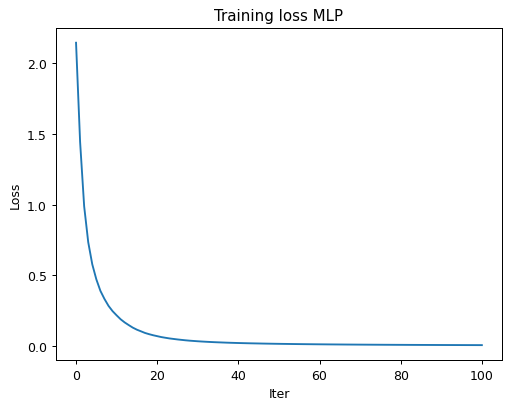

In [16]:
# Get training and test error for the best NN model found using CV
max_iter = 1000
mlp = MLPClassifier(**mlp_best_param, max_iter=max_iter, alpha=1e-4, solver='sgd', tol=1e-4, random_state=ID_number,
                    learning_rate_init=.1,activation=best_activation_type, verbose=True)

# ADD CODE: FIT MODEL & COMPUTE TRAINING AND TEST ERRORS
training_error, test_error = None, None
mlp.fit(x_train,y_train)
training_error = np.float64(1-mlp.score(x_train,y_train))
test_error = np.float64(1-mlp.score(x_test,y_test))
mlp_small_errors = (training_error,test_error)

print ('\nRESULTS FOR BEST NN\n')

print ("Best NN training error: %f" % training_error)
print ("Best NN test error: %f" % test_error)

plt.plot(mlp.loss_curve_, label='Training Loss')
plt.title('Training loss MLP')
plt.xlabel('Iter'), plt.ylabel('Loss')


In [17]:
assert type(training_error) == np.float64
assert type(test_error) == np.float64


## TO DO  5
Write a function to find and plot the first digit (in x_test) that is missclassified by NN and correctly classified by SVM.

Write a function to compute the confusion matrix for the predictions of a model (on testset). If you are not familiar with what a confusion matrix is, have a look at this link: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html . You are not allowed to use sklearn to create the confusion matrix BUT you can compare your solution with the sklearn implementation to check you wrote it right (see assert checks). 

INPUT:
LABEL: 5
SVM: 5 NN: 8
Hardest SVM classes and error rates: [('5', np.float64(0.19511805998723675)), ('8', np.float64(0.19436245572609212)), ('2', np.float64(0.16051873198847266))]
Hardest MLP classes and error rates: [('5', np.float64(0.31812380344607527)), ('8', np.float64(0.25191853600944514)), ('2', np.float64(0.20734870317002885))]
CV-selected family: SVM
Test errors, SVM and MLP: 0.10601438848920863 0.14574100719424465


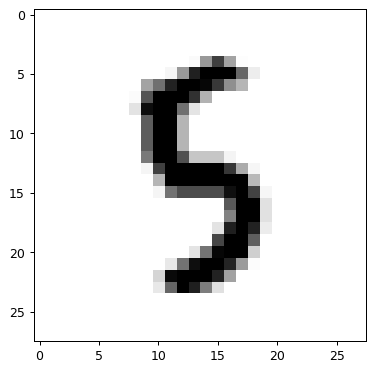

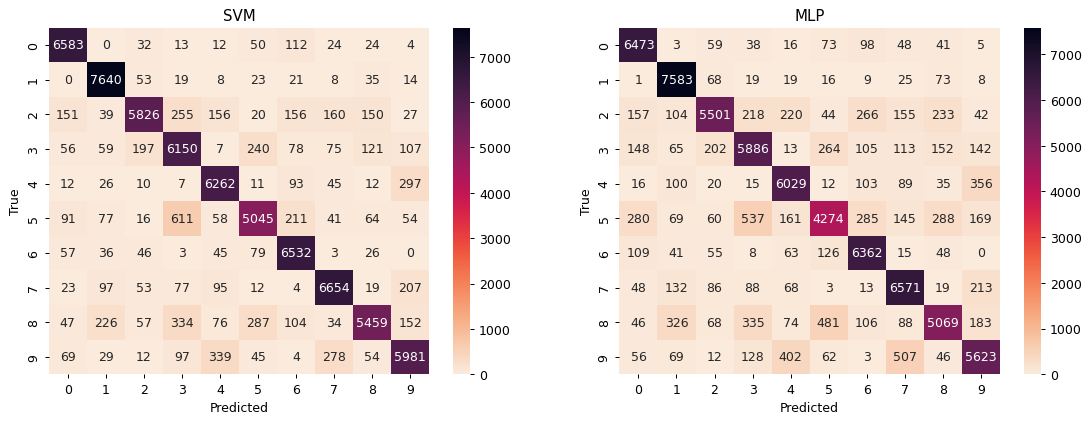

In [18]:
def find_and_print_first_mismatched_prediction(SVM_prediction,NN_prediction,x_test,y_test):
    mask = (np.asarray(SVM_prediction)==np.asarray(y_test)) & (np.asarray(NN_prediction)!=np.asarray(y_test))
    indices = np.flatnonzero(mask)
    if not len(indices):
        print("No digit satisfies the requested mismatch condition.")
        return -1
    i = int(indices[0])
    plot_digit(x_test,y_test,i)
    print("SVM:",SVM_prediction[i],"NN:",NN_prediction[i])
    return i

def confusion_matrix_by_hand(true_labels,predicted_labels):
    y,pred = np.asarray(true_labels).ravel(),np.asarray(predicted_labels).ravel()
    if y.shape != pred.shape:
        raise ValueError("Label arrays must match")
    labels = np.unique(np.r_[y,pred])
    cm = np.zeros((len(labels),len(labels)),dtype=int)
    np.add.at(cm,(np.searchsorted(labels,y),np.searchsorted(labels,pred)),1)
    return cm

def hardest_classes(cm,labels):
    errors = 1-np.divide(np.diag(cm),cm.sum(axis=1),out=np.zeros(len(cm),dtype=float),where=cm.sum(axis=1)>0)
    return list(zip(np.asarray(labels)[np.argsort(errors)[::-1][:3]],np.sort(errors)[::-1][:3]))

SVM_prediction,NN_prediction = best_SVM.predict(x_test),mlp.predict(x_test)
first_index = find_and_print_first_mismatched_prediction(SVM_prediction,NN_prediction,x_test,y_test)
SVM_CM,MLP_CM = confusion_matrix_by_hand(y_test,SVM_prediction),confusion_matrix_by_hand(y_test,NN_prediction)
labels = np.unique(y_test)
SVM_CM_df,MLP_CM_df = pd.DataFrame(SVM_CM,index=labels,columns=labels),pd.DataFrame(MLP_CM,index=labels,columns=labels)
fig,axes = plt.subplots(1,2,figsize=(15,5))
for ax,cm,title in zip(axes,[SVM_CM_df,MLP_CM_df],['SVM','MLP']):
    sn.heatmap(cm,annot=True,fmt='d',ax=ax,cmap='rocket_r')
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
print("Hardest SVM classes and error rates:",hardest_classes(SVM_CM,labels))
print("Hardest MLP classes and error rates:",hardest_classes(MLP_CM,labels))
print("CV-selected family:", 'SVM' if best_svm_cv_score >= best_mlp_cv_score else 'MLP')
print("Test errors, SVM and MLP:",svm_small_errors[1],mlp_small_errors[1])


In [19]:
from sklearn.metrics import confusion_matrix
skl_confusion_matrix_SVM = confusion_matrix(y_test, SVM_prediction)
skl_confusion_matrix_NN = confusion_matrix(y_test, NN_prediction)

assert np.array_equal(skl_confusion_matrix_SVM,SVM_CM)
assert np.array_equal(skl_confusion_matrix_NN,MLP_CM)


## TO DO 6: explain the results you got (max 5 lines)
According to the cross-validation results, would you choose SVMs or NNs when 500 data points are available for training? Is this a good choice, given the results on the test set?

Looking at the confusion matrices what to do you observe? On which classes each model is more likely to make mistakes? 

(Answer in the next cell, no need to add code)

With 500 training images, choose the RBF SVM: five-fold accuracy is 89.20% (C=10, gamma=0.01), versus 86.40% for the best MLP (one 30-unit tanh layer). This choice is supported by test errors of 10.60% and 14.57%, respectively. Both fit the training labels perfectly, so training error alone would not distinguish them. Digits 5, 8, and 2 are the three hardest classes for both models, with MLP class-error rates higher in each case; the off-diagonal matrix entries show the particular confusions.

## More Data

Now let's do the same but using more data points for training SVM and NN. For SVM we are going to use the best hyperparameters set (kernel, C, gamma, ...) found using 500 data points. For NN we are going to use the best architecture found using 500 data points for the relu kernel since such architecture is usually fast to train.

In [20]:
#let restart the random generator with the given seed
np.random.seed(ID_number)

m_t = 60000
x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size=m_t, random_state=ID_number, stratify=Y)

print(f'Lenght train dataset: {len(y_train)}, Labels and frequencies: \n {list(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Lenght test dataset: {len(y_test)}, Labels and frequencies: \n {list(zip(*np.unique(y_test, return_counts=True)))}')


Lenght train dataset: 60000, Labels and frequencies: 
 [('0', np.int64(5917)), ('1', np.int64(6752)), ('2', np.int64(5991)), ('3', np.int64(6121)), ('4', np.int64(5849)), ('5', np.int64(5411)), ('6', np.int64(5894)), ('7', np.int64(6251)), ('8', np.int64(5850)), ('9', np.int64(5964))]
Lenght test dataset: 10000, Labels and frequencies: 
 [('0', np.int64(986)), ('1', np.int64(1125)), ('2', np.int64(999)), ('3', np.int64(1020)), ('4', np.int64(975)), ('5', np.int64(902)), ('6', np.int64(982)), ('7', np.int64(1042)), ('8', np.int64(975)), ('9', np.int64(994))]


In [21]:
# As we did with the first HW let's use a decorator to measure time 
from collections import defaultdict
running_times = defaultdict(list)

def measure_time(function):
    def wrap(*args, **kw):
        import time 
        t_start = time.time()
        result = function(*args, **kw)
        t_end = time.time()
        running_times[type(args[0]).__name__].append(t_end - t_start)
        return result
    return wrap

@measure_time
def fit_classification_model(model, x_train, y_train):
    model.fit(x_train, y_train)


In [22]:
n_data = [250, 500, 1000, 2000, 5000, 7500]
svm_train_err, svm_test_err = [], [] 
mlp_train_err, mlp_test_err = [], [] 
for n in n_data: 
    print(f'Processing with {n} data ...')
    # Initialize models according to the best we got using 500 data
    svm = SVC(kernel=best_kernel_type, **best_parameters)
    mlp = MLPClassifier(**best_param_relu, max_iter=max_iter, alpha=1e-4, solver='sgd', tol=1e-4, 
                        random_state=ID_number, learning_rate_init=.1,activation='relu')

    # fit svc
    fit_classification_model(svm, x_train[:n], y_train[:n])
    # get svc train and test error
    svm_train_err.append(1. - svm.score(x_train[:n], y_train[:n]))
    svm_test_err.append(1. - svm.score(x_test, y_test))
    
    # fit mlp
    fit_classification_model(mlp, x_train[:n], y_train[:n])
    # get mlp train and test error
    mlp_train_err.append(1. - mlp.score(x_train[:n], y_train[:n]))
    mlp_test_err.append(1. - mlp.score(x_test, y_test))


Processing with 250 data ...
Processing with 500 data ...
Processing with 1000 data ...
Processing with 2000 data ...
Processing with 5000 data ...
Processing with 7500 data ...


(<matplotlib.legend.Legend object at 0x7f5237d81880>, Text(0.5, 1.0, 'Training Time'))

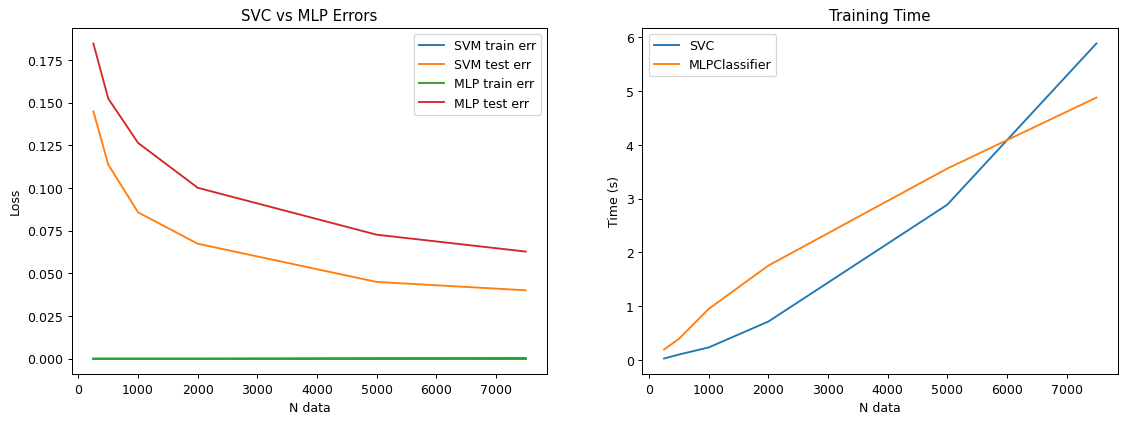

In [23]:
fig, axes = plt.subplots(1,2, figsize=(15, 5))
axes[0].plot(n_data, np.array(svm_train_err), label='SVM train err')
axes[0].plot(n_data, np.array(svm_test_err), label='SVM test err')
axes[0].plot(n_data, np.array(mlp_train_err), label='MLP train err')
axes[0].plot(n_data, np.array(mlp_test_err), label='MLP test err')
axes[0].set_xlabel('N data'), axes[0].set_ylabel('Loss')
axes[0].legend(), axes[0].set_title('SVC vs MLP Errors')

for model, times in running_times.items():
    axes[1].plot(n_data, times, label=model)
axes[1].set_xlabel('N data'), axes[1].set_ylabel('Time (s)')
axes[1].legend(), axes[1].set_title('Training Time')


# TODO 7: Complete dataset
Just for comparison, since it may not be possible to learn a SVM on too many data (due to time and memory complexity issues as you can notice from the plots above), let's use logistic regression (with standard parameters from scikit-learn but the number of iteration).

In [24]:
from sklearn import linear_model
max_iter = 1000
log_reg = linear_model.LogisticRegression(max_iter=max_iter,random_state=ID_number)
fit_classification_model(log_reg,x_train,y_train)
training_error_lr = np.float64(1-log_reg.score(x_train,y_train))
test_error_lr = np.float64(1-log_reg.score(x_test,y_test))
print("Logistic regression training error:",training_error_lr,"Test error:",test_error_lr)


Logistic regression training error: 0.0611666666666667 Test error: 0.07679999999999998


We now learn the NN. Below we use the same best architecture as before (found with 500 data for the relu activation function), feel free to try larger ones (and to use again CV), or smaller ones if it takes too much time. (We suggest that you use 'verbose=True' so have an idea of how long it takes to run 1 iteration). 

*Note*: If you do again CV to choose the best architecture remember to save the best set of parameters into the variable: "best_param_relu".

In [25]:
best_mlp_large = MLPClassifier(**best_param_relu,max_iter=max_iter,alpha=1e-4,solver='sgd',tol=1e-4,
                               random_state=ID_number,learning_rate_init=.1,activation='relu')
fit_classification_model(best_mlp_large,x_train,y_train)
training_error = np.float64(1-best_mlp_large.score(x_train,y_train))
test_error = np.float64(1-best_mlp_large.score(x_test,y_test))
mlp_large_errors = (training_error,test_error)
print("Large MLP training error:",training_error,"Test error:",test_error)


Large MLP training error: 0.0 Test error: 0.03620000000000001


In [26]:
assert type(training_error) == np.float64
assert type(test_error) == np.float64


Hardest logistic classes: [('3', np.float64(0.12254901960784315)), ('8', np.float64(0.12102564102564106)), ('5', np.float64(0.11973392461197341))]
Hardest large-MLP classes: [('3', np.float64(0.05490196078431375)), ('8', np.float64(0.05128205128205132)), ('9', np.float64(0.048289738430583484))]
SVM at 7500 test error: 0.040000000000000036 MLP at 60000: 0.03620000000000001 MLP at 500: 0.14574100719424465


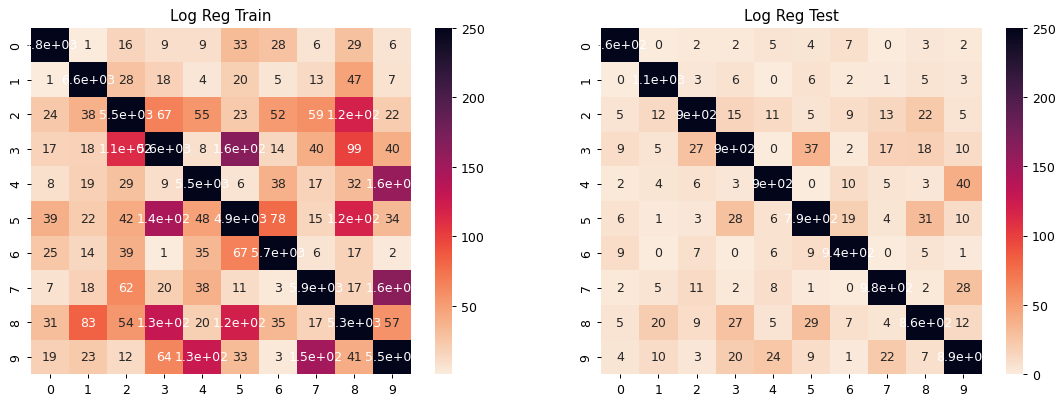

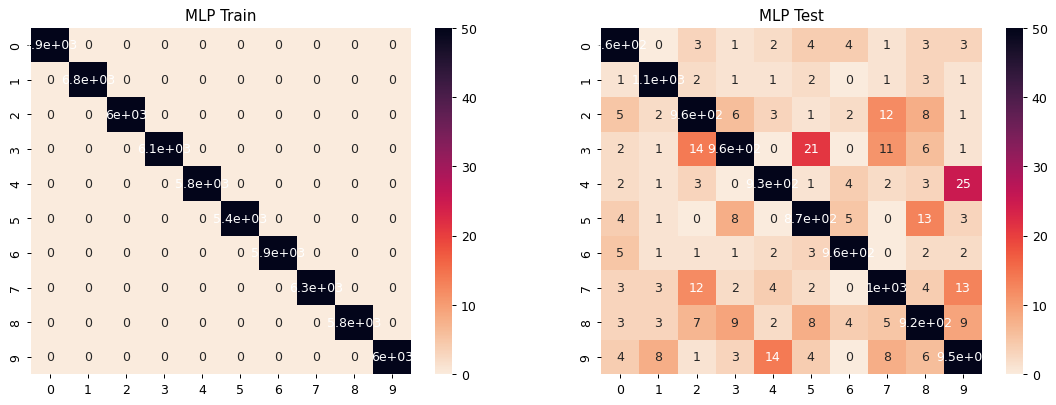

In [27]:
## TODO 8: compute the confusion matrices both on train and test set for Logistic regression (trained on 60k)
# and MLP (trained on 60k).

# Log Reg Confusion matrices
log_reg_CM_train, log_reg_CM_test = None, None
log_reg_CM_train = confusion_matrix_by_hand(y_train,log_reg.predict(x_train))
log_reg_CM_test = confusion_matrix_by_hand(y_test,log_reg.predict(x_test))

# mlp
mlp_CM_train, mlp_CM_test = None, None
mlp_CM_train = confusion_matrix_by_hand(y_train,best_mlp_large.predict(x_train))
mlp_CM_test = confusion_matrix_by_hand(y_test,best_mlp_large.predict(x_test))


# Convert confusion matrices to pandas data frames
labels = np.unique(y_test)
log_reg_CM_train_df = pd.DataFrame(log_reg_CM_train, index = labels, columns = labels)
log_reg_CM_test_df = pd.DataFrame(log_reg_CM_test, index = labels, columns = labels)

mlp_CM_train_df = pd.DataFrame(mlp_CM_train, index = labels, columns = labels)
mlp_CM_test_df = pd.DataFrame(mlp_CM_test, index = labels, columns = labels)

# Plot confusion matrices
fig, axes = plt.subplots(1,2, figsize=(15,5))
sn.heatmap(log_reg_CM_train_df, annot=True, ax=axes[0], cmap='rocket_r', vmax=250)
sn.heatmap(log_reg_CM_test_df, annot=True, ax=axes[1], cmap='rocket_r', vmax=250)
axes[0].set_title('Log Reg Train'), axes[1].set_title('Log Reg Test')

fig, axes = plt.subplots(1,2, figsize=(15,5))
sn.heatmap(mlp_CM_train_df, annot=True, ax=axes[0], cmap='rocket_r', vmax=50)
sn.heatmap(mlp_CM_test_df, annot=True, ax=axes[1], cmap='rocket_r', vmax=50)
axes[0].set_title('MLP Train'), axes[1].set_title('MLP Test')
print("Hardest logistic classes:",hardest_classes(log_reg_CM_test,labels))
print("Hardest large-MLP classes:",hardest_classes(mlp_CM_test,labels))
print("SVM at 7500 test error:",svm_test_err[-1],"MLP at 60000:",mlp_large_errors[1],"MLP at 500:",mlp_small_errors[1])


In [28]:
assert log_reg_CM_train.shape == (10, 10)
assert log_reg_CM_test.shape == (10, 10)
assert mlp_CM_train.shape == (10, 10)
assert mlp_CM_test.shape == (10, 10)


## TO DO 9
Compare and discuss:
- compare the computational time required to fit a SVM and a MLP. Which is faster as the number of data increase? Why? Can you apply both methods in the high data regime?
- the results from SVM m=7500 and NN with m=60000 training data points.
- the results from NN with m=500 and m=60000 training data points.
- What do you observe in the confusion matrices? Which are the hardest classes? Are the hardest and easiest classes the same both for mlp and logistic regression?

(Answer in the next cell, no need to write code)

The measured timing curves show SVC faster at smaller sample sizes, but MLP faster at 7,500; SVC's curve grows more steeply. Kernel optimization and pairwise comparisons scale poorly with sample count, whereas fixed-size MLP minibatch training has roughly linear per-epoch sample cost. Kernel SVM remains possible at larger scales but can be impractical; this notebook trains the MLP on all 60,000 training examples.
The 7,500-example SVM has 4.00% test error, versus 3.62% for the 60,000-example ReLU MLP. The 500-example selected tanh MLP has 14.57% test error, but that comparison also changes activation and test split, so it cannot isolate sample size alone. At matched 7,500 training examples, the ReLU MLP has 6.27% test error versus SVM's 4.00%.
On the large split, logistic regression's hardest digits are 3, 8, 5 and MLP's are 3, 8, 9; the rankings overlap but differ. Digit 1 is easiest for both in these test confusion matrices. Logistic regression has 7.68% overall test error, versus MLP's 3.62%.

## Data normalization

In the following the importance of data normalization before investigated. In particular, a MLP with a (50,50,) architecture and a 'logistic' activation function is trained with the original MNIST data and the effects are analized. 

In [29]:
# data are restored to their original scale 
X = X*255.
print(X[1])

#train-test data split
x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size=m_t, random_state=ID_number, stratify=Y)


[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.  51. 159. 253. 159.  50.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  48. 238. 252. 252. 252. 237.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  54.
 227. 253. 252. 239. 233. 252.  57.   6.   0.   0.   0.   0.   0.   0.
   0. 

In [30]:
normalized_logistic_mlp = MLPClassifier(hidden_layer_sizes=(50,50),max_iter=max_iter,alpha=1e-4,
    activation='logistic',solver='sgd',tol=1e-4,random_state=ID_number,learning_rate_init=.1)
normalized_logistic_mlp.fit(x_train/255.,y_train)
normalized_error = 1-normalized_logistic_mlp.score(x_test/255.,y_test)
raw_logistic_mlp = MLPClassifier(hidden_layer_sizes=(50,50),max_iter=max_iter,alpha=1e-4,
    activation='logistic',solver='sgd',tol=1e-4,random_state=ID_number,learning_rate_init=.1)
raw_logistic_mlp.fit(x_train,y_train)
raw_error = 1-raw_logistic_mlp.score(x_test,y_test)
print("Matched sigmoid MLP test error; normalized:",normalized_error,"raw:",raw_error)
print("Epochs; normalized:",normalized_logistic_mlp.n_iter_,"raw:",raw_logistic_mlp.n_iter_)


Matched sigmoid MLP test error; normalized: 0.02729999999999999 raw: 0.18710000000000004
Epochs; normalized: 85 raw: 57


## TO DO 10

Do you think data normalization is important? Why? Do you observe any difference between the results you obtained before and after scaling the data?

(Answer in the next cell, no need to write code)

Normalization materially improves this matched experiment: the sigmoid MLP has 2.73% test error on [0,1] pixels, versus 18.71% on raw [0,255] pixels. Large raw inputs can saturate sigmoid units and reduce useful gradients, while a fixed learning rate also interacts with scale. Both networks use the same (50,50) architecture, split, seed, and optimizer. The normalized network trains for 85 epochs and the raw network for 57; earlier optimizer stopping does not imply a better solution. Comparing only against the earlier ReLU model would confound scaling with activation and architecture.